# CONFLUENCE Tutorial: Point-Scale Workflow (Snotel Example)

This notebook demonstrates CONFLUENCE's simplest spatial configuration: point-scale modeling. We'll simulate vertical processes at a single location, specifically for a snow monitoring location: [The Loveland Basin SNOTEL Station (id: 602)]('https://wcc.sc.egov.usda.gov/nwcc/site?sitenum=602')

## Overview

Point-scale modeling focuses on vertical processes without spatial heterogeneity here we will compare snow accumulation and melt at the station. 
 
## Learning Objectives

1. Understand point-scale modeling in CONFLUENCE
2. Configure CONFLUENCE for single-point simulations
3. Analyze point-scale SUMMA snow simulations

In [1]:
import easymore

In [2]:
import os
os.getcwd()

'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/examples'

In [3]:
# First we import the libraries we'll need in this tutorial
import sys
import os
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import contextily as cx
import xarray as xr
import numpy as np

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# Set up plotting style
plt.style.use('default')
%matplotlib inline

print("=== CONFLUENCE Tutorial - 1: Point-Scale Workflow - SNOTEL example ===")
print(f"CONFLUENCE path: {confluence_path}")
print(f"Tutorial started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

=== CONFLUENCE Tutorial - 1: Point-Scale Workflow - SNOTEL example ===
CONFLUENCE path: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro
Tutorial started: 2025-08-14 18:16:47


## Create Point-Scale Configuration

We'll use the point configuration template in 0_config_files/0_config_point_template.yaml as our baseline. 

We copy the template to a new location and update teh key configuration settings for our specific experiment.

In [4]:
# Set directory paths 
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data') 
#CONFLUENCE_DATA_DIR = Path('/path/to/your/CONFLUENCE_data') 

# Load template configuration for point-scale modeling
config_template_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_point_template.yaml'

# Read and customize configuration
with open(config_template_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update paths and core experiment settings
config_dict['CONFLUENCE_CODE_DIR'] = str(CONFLUENCE_CODE_DIR)
config_dict['CONFLUENCE_DATA_DIR'] = str(CONFLUENCE_DATA_DIR)
# config_dict['BOUNDING_BOX_COORDS'] = str('46.781/-121.751/46.799/-121.749') currently run for Butte Snotel, this is paradis, WA
# config_dict['POUR_POINT_COORDS'] = str('46.78/-121.75')
config_dict['DOMAIN_DEFINITION_METHOD'] = "point"
config_dict['DOWNLOAD_SNOTEL'] = 'true'
config_dict['HYDROLOGICAL_MODEL'] = "SUMMA"
config_dict['FORCING_DATASET'] = "ERA5"
config_dict['SUPPLEMENT_FORCING'] = 'true'
config_dict['EXPERIMENT_TIME_START'] = "1981-01-01 01:00"
config_dict['EXPERIMENT_TIME_END'] = "1991-12-31 23:00"
config_dict['DOMAIN_NAME'] = 'butte_snotel'  # Name of the domain
config_dict['EXPERIMENT_ID'] = 'point_scale_tutorial'
config_dict['FORCING_PATH'] = f"/scratch/dlhogan/ess-project-data/domain_{config_dict['DOMAIN_NAME']}/forcing/merged_data"  # Path to merged forcing data

# Save configuration 
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_point_notebook.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False, sort_keys=False)

print(f"\n✅ Configuration saved to: {temp_config_path}")


✅ Configuration saved to: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_point_notebook.yaml


## CONFLUENCE System Initialization
Now we are ready to create an instantiation of CONFLUENCE using our new configuration file. 

In [5]:
# Initialize CONFLUENCE with the experiment configuration
confluence = CONFLUENCE(temp_config_path)


18:16:47 │ ============================================================
18:16:47 ● CONFLUENCE Logging Initialized
18:16:47 ● Domain: butte_snotel
18:16:47 ● Experiment ID: point_scale_tutorial
18:16:47 ● Log Level: INFO
18:16:47 ● Log File: /scratch/dlhogan/ess-project-data/domain_butte_snotel/_workLog_butte_snotel/confluence_general_butte_snotel_20250814_181647.log

18:16:47 │ ============================================================
18:16:47 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_butte_snotel/_workLog_butte_snotel/config_butte_snotel_20250814_181647.yaml
18:16:48 ● Initializing CONFLUENCE system
18:16:48 ● Configuration loaded from: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_point_notebook.yaml
18:16:48 ● Creating point domain shapefile from bounding box coordinates
18:16:48 ● Point domain shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/river_basins/butte

## Project Structure Creation and Organization
We can now use CONFLUENCE to setup a project directory for our experiment. 

In [6]:
# Initialize project structure
project_dir = confluence.managers['project'].setup_project()

print(f"\n📁 Project root created: {project_dir}")

# Create spatial reference point (SNOTEL station location)
pour_point_path = confluence.managers['project'].create_pour_point()

print(f"📍 Pour point created: {pour_point_path}")
print(f"   → Location: {config_dict['POUR_POINT_COORDS']} (Paradise SNOTEL)")

# Display the created directory structure
print(f"\n=== Standardized Directory Structure ===")

def display_directory_tree(path, prefix="", max_depth=2, current_depth=0):
    """Display directory tree with scientific context"""
    if current_depth >= max_depth:
        return
    
    items = sorted([item for item in path.iterdir() if item.is_dir()])
    for i, item in enumerate(items):
        is_last = i == len(items) - 1
        current_prefix = "└── " if is_last else "├── "
        print(f"{prefix}{current_prefix}{item.name}")
        
        # Add scientific context for key directories
        if item.name == "forcing":
            print(f"{prefix}{'    ' if is_last else '│   '}    → Meteorological input data")
        elif item.name == "observations": 
            print(f"{prefix}{'    ' if is_last else '│   '}    → Validation datasets (SNOTEL, streamflow)")
        elif item.name == "simulations":
            print(f"{prefix}{'    ' if is_last else '│   '}    → Model output organized by experiment")
        elif item.name == "attributes":
            print(f"{prefix}{'    ' if is_last else '│   '}    → Geospatial characteristics (elevation, soil, land cover)")
        elif item.name == "shapefiles":
            print(f"{prefix}{'    ' if is_last else '│   '}    → Spatial domains and discretization")
            
        if current_depth < max_depth - 1:
            extension = "    " if is_last else "│   "
            display_directory_tree(item, prefix + extension, max_depth, current_depth + 1)

display_directory_tree(project_dir, max_depth=2)

18:16:48 ● Setting up project for domain: butte_snotel
18:16:48 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_butte_snotel

📁 Project root created: /scratch/dlhogan/ess-project-data/domain_butte_snotel
18:16:48 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/pour_point/butte_snotel_pourPoint.shp


📍 Pour point created: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/pour_point/butte_snotel_pourPoint.shp
   → Location: 38.9/-106.95 (Paradise SNOTEL)

=== Standardized Directory Structure ===
├── _workLog_butte_snotel
├── attributes
│       → Geospatial characteristics (elevation, soil, land cover)
│   ├── elevation
│   ├── landclass
│   └── soilclass
├── forcing
│       → Meteorological input data
│   ├── 0_geopotential
│   ├── SUMMA_input
│   ├── merged_data
│   └── raw_data
├── observations
│       → Validation datasets (SNOTEL, streamflow)
│   ├── snow
│   └── streamflow
├── optimisation
├── plots
│   ├── catchment
│   ├── domain
│   └── results
├── settings
│   └── SUMMA
├── shapefiles
│       → Spatial domains and discretization
│   ├── catchment
│   ├── catchment_intersection
│   ├── forcing
│   │       → Meteorological input data
│   ├── pour_point
│   ├── river_basins
│   └── river_network
└── simulations
        → Model output organized by experiment
    

# Step 2: Geospatial Domain Definition and Spatial Discretization

## Scientific Context
Spatial representation is fundamental to hydrological modeling, determining how we conceptualize the landscape and partition it into computational units. The choice of spatial discretization profoundly affects:

- Process Representation: How we capture spatial heterogeneity in climate, topography, vegetation, and soils
- Model Complexity: The trade-off between process detail and computational efficiency
- Scale Dependencies: How processes manifest differently at point, hillslope, and watershed scales
- Validation Strategy: What observations are appropriate for model evaluation

For point-scale modeling, we deliberately minimize spatial complexity to isolate vertical processes. This creates a controlled environment where energy and water balance physics can be evaluated without the confounding effects of lateral flow, spatial heterogeneity, or routing processes.

The spatial representation we establish here contrasts with the distributed watersheds we'll explore in Tutorial 2, where complex topography drives spatial patterns in precipitation, radiation, and runoff generation.

## CONFLUENCE Implementation
CONFLUENCE handles spatial domain definition through three components:

- Attribute Acquisition: Systematic collection of the geospatial characteristics we need to configure our hydrological models (elevation, soil properties, land cover) using standardized datasets
- Domain Delineation: Creation of the primary computational boundary (Grouped Response Units - GRUs)
- Domain Discretization: Subdivision into Hydrologic Response Units (HRUs) based on landscape similarity

For point-scale studies, this process creates a minimal spatial representation:

- Bounding Box: 0.001° × 0.001° square centered on station coordinates
- Single GRU: One computational unit representing the station footprint
- Single HRU: No further subdivision needed for point-scale physics

The same framework scales seamlessly from this minimal representation to complex distributed watersheds with hundreds of HRUs as we'll explore in Tutorials 2 and 3.

## Step 2a: Geospatial Attribute Acquisition
Attributes provide the physical characteristics needed to parameterize model physics. Even for point-scale modeling, we need elevation, soil properties, and vegetation characteristics to constrain energy and water balance processes.

CONFLUENCE uses [gistool (Keshavaraz et al., 2025](https://github.com/CH-Earth/gistool) to subset and aquire the required data.

### ⚠️ Important: HDF4 Support Required

**Before proceeding with attribute acquisition, ensure your environment has HDF4 support for MODIS data processing:**

```bash
conda install -c conda-forge libgdal-hdf4
```

This is required for processing MODIS HDF files. Otherwise it fails silently.

In [7]:
# Acquire geospatial attributes
print(f"\n⬇️  Acquiring attributes through gistool (Model Agnostic Framework)...")
print("   → This may take several minutes ")

confluence.managers['data'].acquire_attributes()

print("✅ Attribute acquisition complete")    


⬇️  Acquiring attributes through gistool (Model Agnostic Framework)...
   → This may take several minutes 
18:16:48 ● Starting attribute acquisition
18:16:48 ● Acquiring elevation data


(2025-08-15 01:16:49) merit_hydro.sh: processing MERIT-Hydro GeoTIFF(s)...
(2025-08-15 01:16:49) merit_hydro.sh: creating cache directory under /scratch/dlhogan/ess-project-data/cache/_butte_snotel
(2025-08-15 01:16:49) merit_hydro.sh: creating output directory under /scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/elevation/dem
(2025-08-15 01:16:49) merit_hydro.sh: untarring MERIT-Hydro variables under /scratch/dlhogan/ess-project-data/cache/_butte_snotel
(2025-08-15 01:16:52) merit_hydro.sh: subsetting GeoTIFFs under /scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/elevation/dem
(2025-08-15 01:16:53) merit_hydro.sh: deleting temporary files from /scratch/dlhogan/ess-project-data/cache/_butte_snotel
(2025-08-15 01:16:53) merit_hydro.sh: temporary files from /scratch/dlhogan/ess-project-data/cache/_butte_snotel are removed
(2025-08-15 01:16:53) merit_hydro.sh: results are produced under /scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/ele

mkdir: cannot create directory ‘/home/dlhogan/empty_dir’: File exists


(2025-08-15 01:17:02) soil_class.sh: processing Wouter's wonderful soil_class GeoTIFF(s)...
(2025-08-15 01:17:02) soil_class.sh: creating output directory under /scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/soilclass
(2025-08-15 01:17:02) soil_class.sh: subsetting GeoTIFFs under /scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/soilclass
(2025-08-15 01:17:02) soil_class.sh: deleting temporary files from /scratch/dlhogan/ess-project-data/cache/_butte_snotel
(2025-08-15 01:17:02) soil_class.sh: temporary files from /scratch/dlhogan/ess-project-data/cache/_butte_snotel are removed
(2025-08-15 01:17:02) soil_class.sh: results are produced under /scratch/dlhogan/ess-project-data/domain_butte_snotel/attributes/soilclass
18:17:02 ● gistool completed successfully.
18:17:02 ● Geospatial data acquisition process completed
18:17:02 ● Attribute acquisition completed successfully
✅ Attribute acquisition complete


mkdir: cannot create directory ‘/home/dlhogan/empty_dir’: File exists


## Step 2b: Domain Delineation (GRU Creation)
Domain delineation creates the primary computational boundary. For point-scale modeling, this is simply a geometric square around our station location, but the same process scales to complex watershed delineation for distributed modeling.

In [8]:
print("Creating primary computational boundary...")

watershed_path = confluence.managers['domain'].define_domain()

print(f"✅ Domain delineation complete")

Creating primary computational boundary...
18:17:02 ● Domain definition workflow starting with: point
18:17:02 ● Point domain shapefile already exists: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/river_basins/butte_snotel_riverBasins_point.shp
18:17:02 ● Domain definition completed using method: point


18:17:03 ● Domain map saved to /scratch/dlhogan/ess-project-data/domain_butte_snotel/plots/domain/domain_map.png
18:17:03 ● Domain definition workflow finished
✅ Domain delineation complete


## Step 2c: Domain Discretization (HRU Creation)
Discretization subdivides GRUs into Hydrologic Response Units based on landscape similarity. For point-scale modeling, we maintain a 1:1 relationship (1 GRU = 1 HRU), but this step demonstrates the framework that enables more complex spatial representations which we will encounter in later notebook sections.

In [9]:
print("Creating Hydrologic Response Units for model execution...")

hru_path = confluence.managers['domain'].discretize_domain()

print(f"✅ Domain discretization complete")

Creating Hydrologic Response Units for model execution...
18:17:03 ● Discretizing domain using method: GRUs
18:17:03 ● Starting domain discretization using attributes: ['GRUs']

18:17:03 │ Step 1/2: Running single attribute discretization method
18:17:03 ● config domain name butte_snotel
18:17:03 ● Calculating mean elevation for each HRU
18:17:03 ● DEM CRS: EPSG:4326
18:17:03 ● Shapefile CRS: EPSG:4326
18:17:03 ● CRS match - no reprojection needed


18:17:03 ● Successfully calculated elevation statistics for 1 HRUs
18:17:03 ● Calculated centroids in WGS84: lat range 38.899922 to 38.899922, lon range -106.950001 to -106.950001
18:17:03 ● GRUs saved as HRUs to /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment/butte_snotel_HRUs_GRUs.shp
18:17:04 ● HRU plot saved to /scratch/dlhogan/ess-project-data/domain_butte_snotel/plots/catchment/butte_snotel_HRUs_as_GRUs.png

18:17:04 │ Step 2/2: Sorting catchment shape
18:17:04 ● Sorting catchment shape
18:17:04 ● Catchment shape sorted and saved to /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment/butte_snotel_HRUs_GRUs.shp
18:17:04 ● Domain discretization completed in 1.17 seconds
18:17:04 ● Domain discretization failed - no shapefile created
✅ Domain discretization complete


## Spatial Visualization

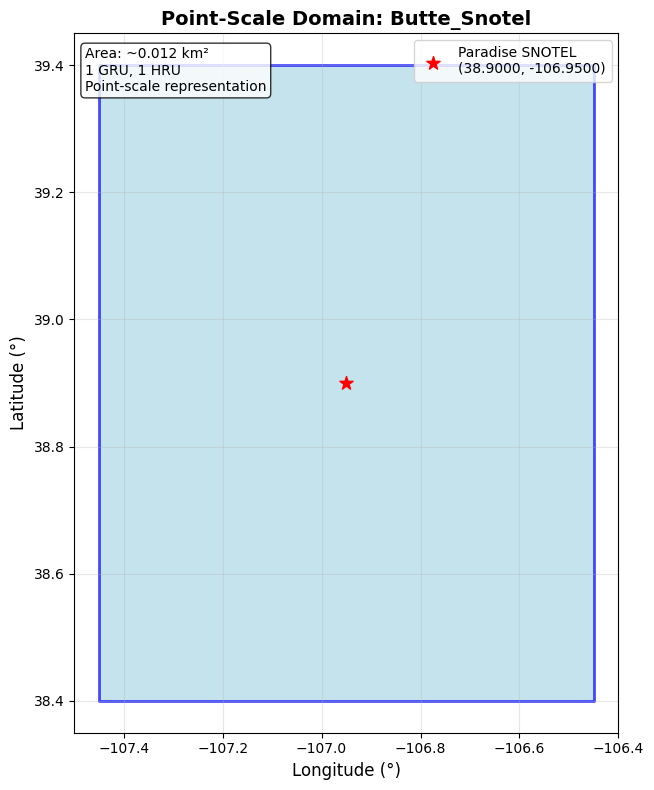

✅ Spatial visualization complete


In [10]:
# Load spatial data
hru_path = confluence.project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"
hru_gdf = gpd.read_file(hru_path)

# Create simple plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot HRU
hru_gdf.plot(ax=ax, facecolor='lightblue', edgecolor='blue', linewidth=2, alpha=0.7)

# Add station point
station_coords = config_dict['POUR_POINT_COORDS'].split('/')
station_lat, station_lon = float(station_coords[0]), float(station_coords[1])
ax.scatter(station_lon, station_lat, c='red', s=100, marker='*', 
          label=f'Paradise SNOTEL\n({station_lat:.4f}, {station_lon:.4f})', zorder=5)

# Styling
ax.set_title(f'Point-Scale Domain: {config_dict["DOMAIN_NAME"].title()}', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude (°)', fontsize=12)
ax.set_ylabel('Latitude (°)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add annotation
ax.text(0.02, 0.98, f"Area: ~0.012 km²\n1 GRU, 1 HRU\nPoint-scale representation", 
       transform=ax.transAxes, fontsize=10, verticalalignment='top',
       bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()

print("✅ Spatial visualization complete")

# Step 3: Input Data Preprocessing and Model-Agnostic Framework
## Scientific Context
Input data preprocessing represents a critical but often overlooked component of hydrological modeling that profoundly affects model performance and scientific conclusions. Traditional approaches tightly couple data preprocessing with specific models, creating several scientific and practical challenges:

- Model Comparison Barriers: Different preprocessing approaches make it difficult to determine whether performance differences arise from model physics or data preparation
- Reproducibility Issues: Model-specific preprocessing pipelines are often poorly documented and difficult to reproduce
- Research Inefficiency: Duplicated preprocessing effort across modeling studies
- Benchmarking Limitations: Inability to evaluate models against consistent baselines

The Model-Agnostic Framework (MAF) philosophy addresses these challenges by separating data preparation from model execution, creating a standardized pipeline that serves multiple modeling applications.

## CONFLUENCE Implementation Philosophy
CONFLUENCE implements a two-stage preprocessing architecture:
Stage 1: Model-Agnostic Preprocessing

- Standardized Data Sources: Consistent meteorological and geospatial datasets
- Unified Spatial Framework: Common geospatial operations across all models
- Quality-Controlled Outputs: Standardized formats with documented provenance
- Reusable Products: Same preprocessed data serves multiple models and analyses

Stage 2: Model-Specific Preprocessing

- Format Translation: Convert standardized outputs to model-required formats
- Model Configuration: Apply model-specific parameter assignments and settings
- Initialization: Prepare model-specific initial conditions and control files

This separation enables true model intercomparison studies, automated benchmarking, and scalable research workflows that maintain scientific rigor while maximizing efficiency.

## Step 3a: Meteorological Forcing Data Acquisition
Meteorological forcing drives all hydrological models, making standardized acquisition critical for reproducible research. CONFLUENCE leverages the Model-Agnostic Framework's [datatool (Keshavarz et al., 2025)](https://github.com/CH-Earth/datatool) to access quality-controlled, globally-consistent datasets.

In [11]:
# Check SLURM availability
import subprocess
import shutil

print("🔍 Checking system requirements...")

# Check if SLURM is available
slurm_available = bool(shutil.which("sbatch"))
print(f"   SLURM (sbatch): {'✅ Available' if slurm_available else '❌ Not available'}")

if not slurm_available:
    print("\n⚠️  SLURM is not available on this system.")
    print("   → CONFLUENCE datatool is designed for HPC environments with SLURM")
    print("   → We'll need to modify the approach to run without job submission")
    
    # Check if we can run datatool directly without job submission
    datatool_path = confluence.config.get('DATATOOL_PATH', 'default')
    if datatool_path == 'default':
        datatool_path = Path(confluence.config['CONFLUENCE_DATA_DIR']) / 'installs/datatool'
    
    datatool_script = Path(datatool_path) / 'extract-dataset.sh'
    datatool_available = datatool_script.exists()
    print(f"   → Datatool script: {'✅ Found' if datatool_available else '❌ Not found'} at {datatool_script}")
    
    if datatool_available:
        print("   → We can try running datatool directly without SLURM job submission")
    else:
        print("   → Datatool not found - may need to install or configure path")
else:
    print("   → System is ready for normal SLURM-based execution")

🔍 Checking system requirements...
   SLURM (sbatch): ❌ Not available

⚠️  SLURM is not available on this system.
   → CONFLUENCE datatool is designed for HPC environments with SLURM
   → We'll need to modify the approach to run without job submission
   → Datatool script: ✅ Found at /home/dlhogan/tools/src/datatool/extract-dataset.sh
   → We can try running datatool directly without SLURM job submission


In [12]:
# Solution: Modify CONFLUENCE to work without SLURM
if not slurm_available:
    print("🔧 Applying non-SLURM workaround...")
    
    # We need to modify the datatool execution approach
    # Option 1: Try to run datatool without the --submit-job flag
    # Option 2: Use a different forcing data approach
    
    # Let's check what forcing dataset we're configured for
    forcing_dataset = confluence.config.get('FORCING_DATASET', 'ERA5')
    print(f"   → Configured forcing dataset: {forcing_dataset}")
    
    # Check if we have alternative data sources available
    project_forcing_dir = confluence.project_dir / "forcing" / "raw_data"
    if project_forcing_dir.exists():
        existing_files = list(project_forcing_dir.glob("*.nc"))
        print(f"   → Existing forcing files: {len(existing_files)} found")
        if existing_files:
            print("     → Forcing data may already be available")
    
    print("\n💡 Potential solutions:")
    print("   1. Modify datatool command to run without --submit-job flag")
    print("   2. Use pre-downloaded forcing data if available")
    print("   3. Install SLURM system-wide (requires admin privileges)")
    print("   4. Use alternative data acquisition method")
    
    # For now, let's try to patch the datatool runner to work without SLURM
    print("\n🛠️  Attempting to patch datatool execution...")
    
    # Import the datatool runner class
    from utils.data.data_utils import datatoolRunner
    
    # Create a patched version that doesn't use --submit-job
    original_create_command = datatoolRunner.create_datatool_command
    
    def patched_create_datatool_command(self, dataset, output_dir, start_date, end_date, lat_lims, lon_lims, variables):
        """Modified version that removes --submit-job flag"""
        dataset_dir = dataset
        if dataset == "ERA5":
            dataset_dir = 'era5'
        elif dataset == "RDRS":
            dataset_dir = 'rdrsv2.1'
        elif dataset == "CASR":
            dataset_dir = 'casrv3.1'
            dataset = 'casr'

        datatool_command = [
            f"{self.datatool_path}/extract-dataset.sh",
            f"--dataset={dataset}",
            f"--dataset-dir={self.config['DATATOOL_DATASET_ROOT']}{dataset_dir}",
            f"--output-dir={output_dir}",
            f"--start-date={start_date}",
            f"--end-date={end_date}",
            f"--lat-lims={lat_lims}",
            f"--lon-lims={lon_lims}",
            f"--variable={variables}",
            f"--prefix=domain_{self.domain_name}_",
            # Removed: f"--submit-job",
            f"--cache={self.tool_cache}",
            f"--cluster={self.config['CLUSTER_JSON']}",
        ] 
        return datatool_command
    
    # Also patch the execute command to handle direct execution
    original_execute_command = datatoolRunner.execute_datatool_command
    
    def patched_execute_datatool_command(self, datatool_command):
        """Modified version that runs directly without job monitoring"""
        try:
            self.logger.info(f"Running datatool directly (no SLURM job submission)")
            self.logger.info(f"Command: {' '.join(datatool_command)}")
            
            # Run the command directly
            result = subprocess.run(datatool_command, check=True, capture_output=True, text=True)
            
            self.logger.info("Datatool execution completed successfully")
            if result.stdout:
                self.logger.info(f"Output: {result.stdout}")
            if result.stderr:
                self.logger.warning(f"Warnings: {result.stderr}")
                
        except subprocess.CalledProcessError as e:
            self.logger.error(f"Error running datatool: {e}")
            if hasattr(e, 'stderr') and e.stderr:
                self.logger.error(f"Command error output: {e.stderr}")
            raise
        except Exception as e:
            self.logger.error(f"Unexpected error during datatool execution: {e}")
            import traceback
            self.logger.error(traceback.format_exc())
            raise
    
    # Apply the patches
    datatoolRunner.create_datatool_command = patched_create_datatool_command
    datatoolRunner.execute_datatool_command = patched_execute_datatool_command
    
    print("   ✅ Applied patches to run datatool without SLURM")
    print("   → Forcing data acquisition will run directly instead of submitting jobs")
else:
    print("✅ SLURM available - no modifications needed")

🔧 Applying non-SLURM workaround...
   → Configured forcing dataset: ERA5
   → Existing forcing files: 936 found
     → Forcing data may already be available

💡 Potential solutions:
   1. Modify datatool command to run without --submit-job flag
   2. Use pre-downloaded forcing data if available
   3. Install SLURM system-wide (requires admin privileges)
   4. Use alternative data acquisition method

🛠️  Attempting to patch datatool execution...
   ✅ Applied patches to run datatool without SLURM
   → Forcing data acquisition will run directly instead of submitting jobs


In [13]:
print("Acquiring standardized meteorological forcing through datatool...")

# confluence.managers['data'].acquire_forcings()

print("✅ Forcing data acquisition complete")

Acquiring standardized meteorological forcing through datatool...
✅ Forcing data acquisition complete


## Step 3b: Observational Data Processing
Observational data provides the ground truth for model evaluation. CONFLUENCE systematically acquires and processes multiple observation types, creating standardized validation datasets that support comprehensive model assessment.

In [14]:
# Execute observational data processing
print(f"\n📥 Processing observational datasets...")
confluence.managers['data'].process_observed_data()

print("✅ Observational data processing complete")


📥 Processing observational datasets...
18:17:05 ● Processing observed data
18:17:05 ● Processing USGS streamflow data directly from API
18:17:05 ● Retrieving discharge data for station 09112500
18:17:05 ● Time period: 1981-01-01 to 2025-08-13
18:17:05 ● Converting from cfs to cms using factor: 0.0283168
18:17:05 ● Using formatted start date: 1981-01-01
18:17:05 ● Using formatted end date: 2025-08-13
18:17:05 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/dv/?site=09112500&format=rdb&parameterCd=00060&startDT=1981-01-01&endDT=2025-08-13


18:17:06 ● Using discharge column: 18852_00060_00003
18:17:06 ● Using datetime column: datetime
18:17:06 ● Dropping 24 rows with non-numeric discharge values
18:17:09 ● Processed streamflow data saved to: /scratch/dlhogan/ess-project-data/domain_butte_snotel/observations/streamflow/preprocessed/butte_snotel_streamflow_processed.csv
18:17:09 ● Total rows in processed data: 391081
18:17:09 ● Number of non-null values: 390507
18:17:09 ● Number of null values: 574
18:17:09 ● Successfully processed USGS data for station 09112500
18:17:09 ● Retrieved 16272 records from 1981-01-01 00:00:00 to 2025-08-13 00:00:00
18:17:09 ● Processing SNOTEL data
18:17:09 ● Found SNOTEL file: /scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL/380_butte_sntl_obs.csv
18:17:09 ● Sample date format: 2021-10-01 08:00:00+00:00
18:17:09 ● Using date format: mixed
18:17:09 ● Processed SNOTEL data saved to /scratch/dlhogan/ess-project-data/domain_butte_snotel/observations/snow/swe/butte_snotel_swe_processed.c

## Step 3c: Model-Agnostic Preprocessing Pipeline
The model-agnostic preprocessing represents the core innovation of CONFLUENCE's data management philosophy. This stage creates standardized, model-independent data products that serve as the foundation for all subsequent modeling activities.

In [15]:
print(f"\n⚙️  Executing model-agnostic preprocessing...")

confluence.managers['data'].run_model_agnostic_preprocessing()

print("✅ Model-agnostic preprocessing complete")


⚙️  Executing model-agnostic preprocessing...
18:17:09 ● Starting model-agnostic preprocessing
18:17:09 ● Running geospatial statistics
18:17:09 ● Starting geospatial statistics calculation
18:17:09 ● Soil statistics already calculated: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
18:17:09 ● Land statistics already calculated: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
18:17:09 ● Elevation statistics already calculated: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp
18:17:09 ● Geospatial statistics completed: 3/3 steps skipped, 0/3 steps executed
18:17:09 ● Running forcing resampling
18:17:09 ● Starting forcing data resampling process


18:17:09 ● Creating ERA5 shapefile
18:17:09 ● Forcing shapefile already exists: /scratch/dlhogan/ess-project-data/domain_butte_snotel/shapefiles/forcing/forcing_ERA5.shp. Skipping creation.
18:17:09 ● Starting forcing remapping process
18:17:09 ● Creating weighted forcing files
18:17:09 ● Found 199 forcing files to process
18:17:09 ● Using parallel processing with 4 CPUs
18:17:09 ● Found 0 already processed files
18:17:09 ● Found 199 files that need processing
18:17:09 ● Processing 199 files in parallel with 4 CPUs
18:17:09 ● Processing 20 batches of up to 10 files each
18:17:09 ● Processing batch 1/20 with 10 files
18:17:10 ● Worker 0: Processing file ERA5_merged_198101.nc
18:17:10 ● Worker 3: Processing file ERA5_merged_198104.nc
18:17:10 ● Worker 2: Processing file ERA5_merged_198103.nc
18:17:10 ● Worker 1: Processing file ERA5_merged_198102.nc
18:17:10 ● Checking CRS for forcing_ERA5.shp: EPSG:4326
18:17:10 ● Checking CRS for forcing_ERA5.shp: EPSG:4326
18:17:10 ● Checking CRS for 

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:2095: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  shp_intC.geometry.iloc[index] = polys
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/pytho

Ended at date and time 2025-08-14 18:17:10.875597
It took 0.675734 seconds to finish creating of the remapping file
---------------------------
Ended at date and time 2025-08-14 18:17:10.890997
It took 0.69156 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
netcdf output file will be compressed at level 4------REMAPPING------

netcdf output file will be compressed at level 4
Ended at date and time 2025-08-14 18:17:10.961388
It took 0.742025 seconds to finish creating of the remapping file
---------------------------
Ended at date and time 2025-08-14 18:17:10.969347
It took 0.749339 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
------REMAPPING------
netcdf output file will be compressed at level 4
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/merged_data/ERA5_merged_198102.nc to /scratch/dlhogan/ess-project-dat

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:939: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lat_value = np.array(ncid.variables[self.var_lat])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:940: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon_value = np.array(ncid.variables[self.var_lon])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymor

...

EASYMORE will remap variable 
 EASYMORE will remap variable spechum 

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:2095: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  shp_intC.geometry.iloc[index] = polys


 spechum from source file to variable    from source file to variable spechum  spechum in remapped netCDF file 
 in remapped netCDF fileEASYMORE will remap variable  
EASYMORE will remap variable windspd   from source file to variable windspd  windspd from source file to variable    in remapped netCDF filewindspd
  in remapped netCDF file
18:28:03 ● Worker 1: Error processing ERA5_merged_199208.nc: 'LWRadAtm'
18:28:03 ● Traceback (most recent call last):
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/data/agnosticPreProcessor.py", line 1625, in _process_forcing_file
    esmr.nc_remapper()
  File "/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py", line 438, in nc_remapper
    self.check_source_nc()
  File "/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py", line 985, in check_source_nc
    temp = list(ncid.variables[var_name].dimensions)
KeyError: 'LWRadAtm'

18:28:03 ● 

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:521: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  shp_int.to_file(self.temp_dir+self.case_name+'_intersected_shapefile.shp') # save the intersected files
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'S_1_GRU_area' to 'S_1_GRU_ar'
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:521: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  shp_int.to_file(self.temp_dir+self.case_name+'_intersected_shapefile.shp') # save the intersected files
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'S_1_basin_name' to 'S_1_basin_'
  ogr_write(
/home/dl

Ended at date and time 2025-08-14 18:28:03.600488
It took 0.69948 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
Ended at date and time 2025-08-14 18:28:03.650718
It took 0.749365 seconds to finish creating of the remapping file
---------------------------netcdf output file will be compressed at level
 4
------REMAPPING------
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/merged_data/ERA5_merged_199111.nc to /scratch/dlhogan/ess-project-data/domain_butte_snotel/forcing/basin_averaged_data/butte_snotel_ERA5_remapped_ERA5_merged_199111.nc 
Started at date and time 2025-08-14 18:28:03.662140 
Ended at date and time 2025-08-14 18:28:19.121833 
It took 15.459693 seconds to finish the remapping of variable(s) 
---------------------
---------------------
18:28:19 ● Worker 0: Successfully processed ERA5_merged_199111.nc in 16.41 seconds
Remapping /scratch/dlhogan/ess-pr

## Step 3d: Model-Specific Preprocessing
Model-specific preprocessing translates the standardized model-agnostic products into the formats and configurations required by individual models. This stage maintains the scientific benefits of standardized inputs while accommodating diverse model requirements.

Remapping of the forcing data and zonal statistics calculations for the geospatial attributes is performed in one model-agnostic pre-processing step. 

In [16]:
print(f"\n🔧 Executing SUMMA-specific preprocessing...")

confluence.managers['model'].preprocess_models()

print("✅ Model-specific preprocessing complete")


🔧 Executing SUMMA-specific preprocessing...
18:28:24 ● Starting model-specific preprocessing
18:28:24 ● Processing model: SUMMA
18:28:24 ● Starting SUMMA spatial preprocessing
18:28:24 ● Starting memory-efficient temperature lapse rate and data step application
18:28:24 ● Loading topology data...
18:28:24 ● Loaded topology data: 25 rows, 0.02 MB
18:28:24 ● Found 132 forcing files to process
18:28:24 ● Pre-calculating lapse rate corrections...
18:28:24 ● Prepared lapse corrections for 1 HRUs
18:28:24 ● Processing files in batches of 100


18:28:37 ● Completed processing of 132 ERA5 forcing files with temperature lapsing
18:28:37 ● Copying SUMMA base settings
18:28:37 ● SUMMA base settings copied to /scratch/dlhogan/ess-project-data/domain_butte_snotel/settings/SUMMA
18:28:37 ● Creating SUMMA file manager
18:28:37 ● SUMMA file manager created at /scratch/dlhogan/ess-project-data/domain_butte_snotel/settings/SUMMA/fileManager.txt
18:28:37 ● Creating forcing file list
18:28:37 ● Found 132 ERA5 forcing files
18:28:37 ● Forcing file list created at /scratch/dlhogan/ess-project-data/domain_butte_snotel/settings/SUMMA/forcingFileList.txt with 132 files
18:28:37 ● Creating initial conditions (cold state) file
18:28:37 ● Creating initial conditions (cold state) file
18:28:37 ● Initial conditions file created at: /scratch/dlhogan/ess-project-data/domain_butte_snotel/settings/SUMMA/coldState.nc
18:28:37 ● Creating trial parameters file
18:28:37 ● Trial parameters file created at: /scratch/dlhogan/ess-project-data/domain_butte_snot

# Step 4: Model Instantiation and Process-Based Simulation
## Scientific Context
Model instantiation represents the critical transition from static data preparation to dynamic process simulation. This step transforms spatially-distributed inputs and temporally-varying forcing into evolving hydrological states through the explicit representation of physical processes.
In process-based hydrological modeling, we solve coupled differential equations representing:

- Energy Balance: Net radiation partitioning between sensible, latent, and ground heat fluxes
- Water Balance: Precipitation partitioning among interception, infiltration, evapotranspiration, and runoff
- Snow Physics: Accumulation, metamorphism, and melt processes with explicit energy considerations
- Soil Hydrology: Infiltration, redistribution, and drainage through layered soil profiles
- Vegetation Dynamics: Canopy interception, transpiration, and phenological controls

The SUMMA (Structure for Unifying Multiple Modeling Alternatives) framework enables systematic evaluation of process representations, making it ideal for scientific hypothesis testing and model physics assessment.

## CONFLUENCE Implementation
CONFLUENCE manages model execution through several integrated components:

- Workflow Orchestration: Automated sequencing of model initialization, spinup, and main simulation
- Configuration Management: Translation of scientific decisions into model-specific control files
- Execution Monitoring: Real-time tracking of model progress and error detection
- Output Organization: Systematic storage and cataloging of simulation results
- Quality Assurance: Automated checks for mass balance closure and physical realism

This framework ensures that model execution is reproducible, traceable, and scientifically rigorous, while handling the computational complexity behind the scenes.

In [17]:
print(f"\nRunning {confluence.config['HYDROLOGICAL_MODEL']} for point-scale simulation...")

confluence.managers['model'].run_models()

print("\nPoint-scale model run complete")


Running SUMMA for point-scale simulation...
18:28:51 ● Starting model runs
18:28:51 ● Running model: SUMMA
18:28:51 ● Starting SUMMA run
18:28:51 ● SUMMA run failed with error: Command '/usr/bin/summa/summa.exe -m /scratch/dlhogan/ess-project-data/domain_butte_snotel/settings/SUMMA/fileManager.txt' returned non-zero exit status 127.
18:28:51 ● Error during SUMMA model run: Command '/usr/bin/summa/summa.exe -m /scratch/dlhogan/ess-project-data/domain_butte_snotel/settings/SUMMA/fileManager.txt' returned non-zero exit status 127.
18:28:51 ● Traceback (most recent call last):
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/model_manager.py", line 241, in run_models
    getattr(runner, method_name)()
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/summa_utils.py", line 1833, in run_summa
    self.run_summa_serial()
  File "/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/utils/models/summa_utils.py", line 2269, in run_

18:28:51 ● Could not read simulation file /scratch/dlhogan/ess-project-data/domain_butte_snotel/simulations/point_scale_tutorial/SUMMA/point_scale_tutorial_timestep.nc: [Errno 2] No such file or directory: '/scratch/dlhogan/ess-project-data/domain_butte_snotel/simulations/point_scale_tutorial/SUMMA/point_scale_tutorial_timestep.nc'
18:28:51 ● No simulation data could be loaded
18:28:51 ● Model runs completed

Point-scale model run complete


# Step 5: Model Evaluation and Process Validation
## Scientific Context
Model evaluation represents the critical test of whether our process-based simulation captures the essential physics of the real-world system. Effective evaluation requires:

- Multi-Variable Assessment: Testing multiple aspects of the hydrological system to avoid equifinality and ensure robust process representation
- Temporal Pattern Analysis: Evaluating both magnitude and timing of hydrological responses across seasonal cycles
- Process-Specific Metrics: Using evaluation criteria that reflect the underlying physics being tested
- Uncertainty Quantification: Understanding both observational and model uncertainty in performance assessment

For point-scale modeling, we focus on direct process validation where observations closely match the spatial and temporal scales of model representation. The Paradise SNOTEL station provides co-located snow water equivalent and multi-depth soil moisture observations.

In [ ]:
# Load simulation data
sim_dir = confluence.project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
daily_output_path = sim_dir / f"{config_dict['EXPERIMENT_ID']}_day.nc"

# Load and prepare the evaluation dataset
ds = xr.open_dataset(daily_output_path)

# Skip spinup period
start_year = ds.time.dt.year.min().values + 1
spinup_end = f"{start_year}-01-01"
time_mask = ds.time >= pd.to_datetime(spinup_end)
evaluation_data = ds.isel(time=time_mask)

# Load observed SWE data
obs_swe_path = confluence.project_dir / "observations" / "snow" / "snotel" / "processed" / f"{config_dict['DOMAIN_NAME']}_swe_processed.csv"

obs_swe = pd.read_csv(obs_swe_path, parse_dates=['Date'], dayfirst=True)
obs_swe.set_index('Date', inplace=True)

# Ensure proper datetime index
if not isinstance(obs_swe.index, pd.DatetimeIndex):
    obs_swe.index = pd.to_datetime(obs_swe.index)

# Extract simulated SWE
sim_swe = evaluation_data['scalarSWE'].to_pandas()

# Find common period and align data
start_date = max(obs_swe.index.min(), sim_swe.index.min())
end_date = min(obs_swe.index.max(), sim_swe.index.max())

# Resample to daily and filter to common period
obs_daily = obs_swe.resample('D').mean().loc[start_date:end_date]
sim_daily = sim_swe.resample('D').mean().loc[start_date:end_date]

# Handle different column names for SWE
if 'SWE' in obs_daily.columns:
    obs_values = obs_daily['SWE']
elif 'swe' in obs_daily.columns:
    obs_values = obs_daily['swe']
else:
    # Use first column
    obs_values = obs_daily.iloc[:, 0]

# Convert sim_daily to Series if it's a DataFrame
if isinstance(sim_daily, pd.DataFrame):
    if len(sim_daily.columns) == 1:
        sim_daily = sim_daily.iloc[:, 0]  # Extract the single column as Series

# Remove NaN values for metrics calculation
valid_mask = ~(obs_values.isna() | sim_daily.isna())
obs_valid = obs_values[valid_mask]
sim_valid = sim_daily[valid_mask]

print(f"\n📊 Snow Water Equivalent Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()
corr = obs_valid.corr(sim_valid)

# Percent bias
pbias = 100 * bias / obs_valid.mean()

# Nash-Sutcliffe Efficiency
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency
kge_corr = obs_valid.corr(sim_valid)
kge_bias = sim_valid.mean() / obs_valid.mean()
kge_var = (sim_valid.std() / obs_valid.std())
kge = 1 - np.sqrt((kge_corr - 1)**2 + (kge_bias - 1)**2 + (kge_var - 1)**2)

# Display metrics
print(f"   Root Mean Square Error (RMSE): {rmse:.2f} mm")
print(f"   Mean Absolute Error (MAE): {mae:.2f} mm")
print(f"   Bias: {bias:+.2f} mm ({pbias:+.1f}%)")
print(f"   Correlation: {corr:.3f}")
print(f"   Nash-Sutcliffe Efficiency: {nse:.3f}")
print(f"   Kling-Gupta Efficiency: {kge:.3f}")

# Snow-specific metrics
print(f"\n❄️  Snow-Specific Performance Assessment:")

# Peak SWE analysis
obs_peak = obs_valid.max()
sim_peak = sim_valid.max()
peak_bias = sim_peak - obs_peak
peak_pbias = 100 * peak_bias / obs_peak

print(f"       Peak SWE:")
print(f"       Observed: {obs_peak:.1f} mm")
print(f"       Simulated: {sim_peak:.1f} mm")
print(f"       Bias: {peak_bias:+.1f} mm ({peak_pbias:+.1f}%)")

# Snow season timing
obs_peak_date = obs_valid.idxmax()
sim_peak_date = sim_valid.idxmax()
timing_diff = (sim_peak_date - obs_peak_date).days

print(f"       Peak Timing:")
print(f"       Observed peak: {obs_peak_date.strftime('%B %d, %Y')}")
print(f"       Simulated peak: {sim_peak_date.strftime('%B %d, %Y')}")
print(f"       Timing difference: {timing_diff:+d} days")

# Snow season length
snow_threshold = 10  # mm
obs_snow_days = (obs_valid > snow_threshold).sum()
sim_snow_days = (sim_valid > snow_threshold).sum()

print(f"       Snow Season (SWE > {snow_threshold} mm):")
print(f"       Observed: {obs_snow_days} days")
print(f"       Simulated: {sim_snow_days} days")
print(f"       Difference: {sim_snow_days - obs_snow_days:+d} days")

# Create  visualization
print(f"\n Creating SWE comparison visualization...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot
ax1 = axes[0, 0]
ax1.plot(obs_daily.index, obs_values, 'o-', label='Observed', 
         color='black', alpha=0.7, markersize=3, linewidth=1)
ax1.plot(sim_daily.index, sim_daily, '-', label='Simulated', 
         color='blue', linewidth=2)
ax1.set_title('Snow Water Equivalent Time Series', fontsize=12, fontweight='bold')
ax1.set_ylabel('SWE (mm)', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add performance metrics as text
metrics_text = f'RMSE: {rmse:.1f} mm\nBias: {bias:+.1f} mm\nCorr: {corr:.3f}\nNSE: {nse:.3f}'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes, 
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.6, c='blue', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed SWE (mm)', fontsize=11)
ax2.set_ylabel('Simulated SWE (mm)', fontsize=11)
ax2.set_title('Observed vs. Simulated SWE', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_aspect('equal', adjustable='box')

# Seasonal cycle
ax3 = axes[1, 0]
obs_monthly = obs_values.groupby(obs_values.index.month).mean()
sim_monthly = sim_daily.groupby(sim_daily.index.month).mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax3.plot(range(1, 13), obs_monthly, 'o-', label='Observed', color='black', linewidth=2)
ax3.plot(range(1, 13), sim_monthly, 'o-', label='Simulated', color='blue', linewidth=2)
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels(months, rotation=45)
ax3.set_ylabel('Mean SWE (mm)', fontsize=11)
ax3.set_title('Seasonal Cycle', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Residuals over time
ax4 = axes[1, 1]
residuals = sim_valid - obs_valid
ax4.scatter(obs_valid.index, residuals, alpha=0.6, c='red', s=15)
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax4.axhline(y=residuals.std(), color='red', linestyle='--', alpha=0.5, label=f'±1σ ({residuals.std():.1f} mm)')
ax4.axhline(y=-residuals.std(), color='red', linestyle='--', alpha=0.5)
ax4.set_ylabel('Residuals (Sim - Obs) [mm]', fontsize=11)
ax4.set_title('Model Residuals Over Time', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.suptitle(f'Snow Water Equivalent Evaluation - {config_dict["DOMAIN_NAME"].title()}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5b: Soil Moisture Profile Evaluation
Soil moisture evaluation tests the model's representation of vadose zone processes, including infiltration, drainage, and vertical redistribution. Multi-depth observations provide unprecedented validation opportunities for soil physics.

In [ ]:
# Load observed soil moisture data
obs_sm_path = confluence.project_dir / "observations" / "soil_moisture" / "ismn" / "processed" / f"{config_dict['DOMAIN_NAME']}_sm_processed.csv"

# Load observed data
obs_sm = pd.read_csv(obs_sm_path, parse_dates=['timestamp'])
obs_sm.set_index('timestamp', inplace=True)

# Ensure proper datetime index
if not isinstance(obs_sm.index, pd.DatetimeIndex):
    obs_sm.index = pd.to_datetime(obs_sm.index)

# Identify observed depth columns
obs_depth_cols = [col for col in obs_sm.columns if col.startswith('sm_')]

# Extract observed depth values
obs_depths = []
for depth_col in obs_depth_cols:
    # Extract depth from column name (e.g., 'sm_0.0508_0.0508' -> 0.0508)
    depth_str = depth_col.split('_')[1]
    obs_depths.append(float(depth_str))

# Extract simulated soil moisture

sim_sm = evaluation_data['mLayerVolFracLiq']
sim_depths = evaluation_data['mLayerDepth']
    
# Calculate representative layer depths
mean_layer_depths = sim_depths.mean(dim='time')
valid_layers = mean_layer_depths > 0  # Filter out invalid layers
    
# Find common period
start_date = max(obs_sm.index.min(), pd.to_datetime(sim_sm.time.min().values))
end_date = min(obs_sm.index.max(), pd.to_datetime(sim_sm.time.max().values))
    
# Filter to common period
obs_period = obs_sm.loc[start_date:end_date]
sim_time_mask = (sim_sm.time >= start_date) & (sim_sm.time <= end_date)
sim_period = sim_sm.isel(time=sim_time_mask)
sim_depths_period = sim_depths.isel(time=sim_time_mask)
    
n_depths = len(obs_depth_cols)
depth_results = {}

# Analyze each observed depth
for i, (depth_col, obs_depth) in enumerate(zip(obs_depth_cols, obs_depths)):
    print(f"\n     Depth {i+1}: {obs_depth:.4f}m ({depth_col})")
    
    # Find closest simulated layer
    mean_depths = sim_depths_period.mean(dim='time')
    valid_mask = mean_depths > 0
    
    if valid_mask.sum() > 0:
        valid_mean_depths = mean_depths.where(valid_mask)
        depth_differences = np.abs(valid_mean_depths - obs_depth)
        closest_layer_idx = depth_differences.argmin().values
        closest_layer_depth = valid_mean_depths[closest_layer_idx].values
        
        
        # Extract data for this layer
        obs_layer = obs_period[depth_col]
        sim_layer = sim_period.isel(midToto=closest_layer_idx, hru=0)
        
        # Convert to pandas for easier handling
        sim_layer_ts = sim_layer.to_pandas()
        
        # Resample to daily and align
        obs_daily = obs_layer.resample('D').mean()
        sim_daily = sim_layer_ts.resample('D').mean()
        
        # Remove invalid values (negative soil moisture indicates missing data)
        sim_daily = sim_daily.where(sim_daily > -100)
        
        # Find valid paired data
        valid_data_mask = ~(obs_daily.isna() | sim_daily.isna())
        obs_valid = obs_daily[valid_data_mask]
        sim_valid = sim_daily[valid_data_mask]
        
        if len(obs_valid) > 10:  # Require minimum data for meaningful evaluation
            # Calculate performance metrics
            rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
            bias = (sim_valid - obs_valid).mean()
            mae = np.abs(obs_valid - sim_valid).mean()
            corr = obs_valid.corr(sim_valid)
            
            # Store results
            depth_results[obs_depth] = {
                'obs_valid': obs_valid,
                'sim_valid': sim_valid,
                'rmse': rmse,
                'bias': bias,
                'mae': mae,
                'corr': corr,
                'layer_idx': closest_layer_idx,
                'sim_depth': closest_layer_depth
            }
            
            print(f"       RMSE: {rmse:.3f} m³/m³")
            print(f"       Bias: {bias:+.3f} m³/m³")
            print(f"       Correlation: {corr:.3f}")
            print(f"       Valid pairs: {len(obs_valid)}")
            
# Create  visualization
print(f"\n  Creating soil moisture profile evaluation...")

n_depths = len(depth_results)
fig, axes = plt.subplots(n_depths, 2, figsize=(15, 4*n_depths))

if n_depths == 1:
    axes = axes.reshape(1, -1)

for i, (obs_depth, results) in enumerate(depth_results.items()):
    # Time series plot
    ax_ts = axes[i, 0]
    ax_ts.plot(results['obs_valid'].index, results['obs_valid'], 'o-', 
              label=f'Observed ({obs_depth:.4f}m)', 
              color='black', alpha=0.7, markersize=2, linewidth=1)
    ax_ts.plot(results['sim_valid'].index, results['sim_valid'], '-', 
              label=f'Simulated (L{results["layer_idx"]}, {results["sim_depth"]}m)', 
              color='blue', linewidth=2)
    
    ax_ts.set_title(f'Soil Moisture at {obs_depth:.4f}m depth', fontsize=11, fontweight='bold')
    ax_ts.set_ylabel('Soil Moisture (m³/m³)', fontsize=10)
    ax_ts.grid(True, alpha=0.3)
    ax_ts.legend(fontsize=9)
    
    # Add metrics
    metrics_text = (f"RMSE: {results['rmse']:.3f}\n"
                   f"Bias: {results['bias']:+.3f}\n"
                   f"Corr: {results['corr']:.3f}")
    ax_ts.text(0.02, 0.95, metrics_text, transform=ax_ts.transAxes,
              bbox=dict(facecolor='white', alpha=0.8), fontsize=9, verticalalignment='top')
    
    # Scatter plot
    ax_scatter = axes[i, 1]
    ax_scatter.scatter(results['obs_valid'], results['sim_valid'], 
                      alpha=0.6, c='blue', s=15)
    
    # 1:1 line
    min_val = min(results['obs_valid'].min(), results['sim_valid'].min())
    max_val = max(results['obs_valid'].max(), results['sim_valid'].max())
    ax_scatter.plot([min_val, max_val], [min_val, max_val], 'k--', 
                   label='1:1 line', alpha=0.7)
    
    ax_scatter.set_xlabel('Observed SM (m³/m³)', fontsize=10)
    ax_scatter.set_ylabel('Simulated SM (m³/m³)', fontsize=10)
    ax_scatter.set_title(f'Obs vs Sim at {obs_depth:.4f}m', fontsize=11, fontweight='bold')
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend(fontsize=9)
    ax_scatter.set_aspect('equal', adjustable='box')

plt.suptitle(f'Soil Moisture Profile Evaluation - {config_dict["DOMAIN_NAME"].title()}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary performance assessment
print(f"\n  Soil Moisture Profile Performance Summary:")

avg_rmse = np.mean([r['rmse'] for r in depth_results.values()])
avg_corr = np.mean([r['corr'] for r in depth_results.values()])
avg_bias = np.mean([r['bias'] for r in depth_results.values()])

print(f"       Profile-averaged metrics:")
print(f"       Average RMSE: {avg_rmse:.3f} m³/m³")
print(f"       Average correlation: {avg_corr:.3f}")
print(f"       Average bias: {avg_bias:+.3f} m³/m³")

# Close evaluation dataset
evaluation_data.close()

# Tutorial Summary and Next Steps

## Summary: Point-Scale Snow and Soil Process Evaluation

This tutorial demonstrated the complete CONFLUENCE workflow for point-scale hydrological modeling, establishing fundamental principles for reproducible computational hydrology research. Through the Paradise SNOTEL case study, we illustrated how standardized workflows can bridge the gap between complex modeling frameworks and practical scientific applications while maintaining scientific rigor and reproducibility.

### Key Methods
The tutorial successfully demonstrated CONFLUENCE's core capabilities through five integrated workflow components. Reproducible workflow management was achieved through configuration-driven experiments that provide complete provenance tracking and ensure experimental transparency. The model-agnostic preprocessing pipeline creates standardized data products that enable true model physics comparisons by separating data preparation from model-specific requirements. Process-based simulation was implemented using SUMMA's modular physics to explicitly represent energy and water balance processes at the point scale. Multi-variable validation leveraged co-located snow water equivalent and multi-depth soil moisture observations to provide comprehensive model evaluation. Finally, scientific interpretation linked quantitative performance metrics to underlying physical processes, moving beyond statistical assessment to process understanding.

### Scientific Process Validation
The tutorial validated key hydrological processes across multiple temporal scales and physical domains. Snow physics evaluation included accumulation, metamorphism, and energy-balance driven melt processes, with assessment of both magnitude and timing accuracy. Soil hydrology validation examined multi-depth moisture dynamics and vertical water redistribution through four soil layers, testing infiltration and drainage representations. Energy balance processes were implicitly evaluated through successful simulation of temperature-driven phase changes and moisture dynamics. Temporal dynamics were assessed from daily to seasonal time scales, capturing both rapid response and longer-term memory effects. Physical realism was maintained through mass and energy conservation checks and realistic state variable bounds.

### CONFLUENCE Framework Demonstration
This tutorial showcased CONFLUENCE's modular architecture through specialized managers that handle distinct workflow components while maintaining system integration. Workflow orchestration capabilities were demonstrated through automated step sequencing. The scalable design principle was established, showing how the same framework structure supports applications from point-scale studies through continental-scale analyses. Research continuity was ensured by creating a foundation that directly enables progression to distributed modeling and large-sample comparative studies in subsequent tutorials.

### Next Focus: Evapotranspiration and Energy Balance Processes

**Ready to explore energy flux validation?** → **[Tutorial 01b: Point-Scale Energy Balance Validation](./01b_point_scale_fluxnet.ipynb)**